# 05_3 — Live Scoring con GBDT

Scoring de mercados activos usando el modelo primario: `HistGradientBoostingClassifier`.

Este notebook lee los artefactos ya generados en `data/models/registry/` — no reentrena ni rescora.
Para regenerar el scoring: `python -m src.scoring.scorer --config config/config.yaml --all-models`

El GBDT es el único modelo que supera al benchmark de mercado en Brier y log-loss sobre el test set.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.config import load_config

cfg = load_config(str(ROOT / 'config' / 'config.yaml'))
REGISTRY = ROOT / 'data' / 'models' / 'registry'
GBDT_DIR = ROOT / 'data' / 'models' / 'hist_gradient_boosting'
MODEL_NAME = 'hist_gradient_boosting'

print('Registry:', REGISTRY)

Registry: /Users/andres/Documents/ITAM/octavo_semestre/mineria_y_analisis/proyecto_polymarket/data/models/registry


## 1. Cargar modelo y métricas offline

In [2]:
with open(GBDT_DIR / 'run_config.json') as f:
    run_config = json.load(f)
with open(GBDT_DIR / 'test_metrics.json') as f:
    test_metrics = json.load(f)
with open(REGISTRY / 'live_scoring_summary.json') as f:
    live_summary = json.load(f)

tm  = test_metrics['test']
raw = tm['raw_metrics']
mkt = tm['market_baseline_metrics']
beaten = test_metrics.get('market_baseline_beaten', {})

print('=== Resumen offline (test set) ===')
print(f"  Brier:    {raw['brier']:.5f}  vs mercado {mkt['brier']:.5f}  {'✓ GANA' if beaten.get('brier') else '✗'}")
print(f"  Log-loss: {raw['log_loss']:.5f}  vs mercado {mkt['log_loss']:.5f}  {'✓ GANA' if beaten.get('log_loss') else '✗'}")
print(f"  ROC-AUC:  {raw['roc_auc']:.5f}")
print()

ev = tm['ev_metrics']
print(f"  Top-{ev.get('top_k', 'K')} hit rate  : {ev.get('top_k_hit_rate', 'N/A')}")
print(f"  Top-{ev.get('top_k', 'K')} avg PnL  : {ev.get('top_k_avg_realized_pnl', 'N/A'):.4f}")

=== Resumen offline (test set) ===
  Brier:    0.00459  vs mercado 0.00618  ✓ GANA
  Log-loss: 0.01770  vs mercado 0.02210  ✓ GANA
  ROC-AUC:  0.99972

  Top-100 hit rate  : 0.77
  Top-100 avg PnL  : 0.1102


## 2. Cargar scores de mercados activos

In [3]:
df_all = pd.read_csv(REGISTRY / 'live_scores.csv')
df_scores = df_all[df_all['model_name'] == MODEL_NAME].copy()

print(f'Mercados activos scored: {len(df_scores):,}')
print(f'Columnas: {list(df_scores.columns)}')
print()

cols_display = ['question', 'price_yes', 'p_yes_calibrated', 'ev_per_share',
                'expected_roi_capped', 'days_to_end', 'signal']
display(df_scores[cols_display].head(10))

Mercados activos scored: 534
Columnas: ['model_name', 'id', 'question', 'slug', 'price_yes', 'p_yes_raw', 'p_yes_calibrated', 'ev_per_share', 'expected_roi', 'days_to_end', 'liquidity', 'volume_24h', 'spread', 'end_date', 'signal', 'expected_roi_capped', 'signal_strength']



,question,price_yes,p_yes_calibrated,ev_per_share,expected_roi_capped,days_to_end,signal
1068,Will Bitcoin hit $60k or $80k first?,0.570,0.827177,0.257177,0.451187,263.090527,HOLD
1069,Will another country conduct military action a...,0.280,0.487446,0.207446,0.740878,16.882194,STRONG BUY
1070,"Will Bitcoin dip to $65,000 in April?",0.625,0.823618,0.198618,0.317789,18.048860,STRONG BUY
1071,Will Israel launch a ground operation in Iran ...,0.280,0.459687,0.179687,0.641741,47.882194,HOLD
1072,Kash Patel out by April 30?,0.215,0.382279,0.167279,0.778041,77.882194,HOLD
1073,Will the U.S. invade Iran before 2027?,0.585,0.749796,0.164796,0.281702,261.882194,HOLD
1074,"Will Bitcoin dip to $55,000 by December 31, 2026?",0.745,0.908972,0.163972,0.220096,263.090527,HOLD
1075,Will another country conduct military action a...,0.165,0.324717,0.159717,0.967982,1.882194,STRONG BUY
1076,Will Ukraine re-enter Rodynske by April 30?,0.470,0.624192,0.154192,0.328068,16.882194,STRONG BUY
1077,Will WTI Crude Oil (WTI) hit (HIGH) $120 in Ap...,0.685,0.824218,0.139218,0.203239,18.048860,STRONG BUY


## 3. Distribución de señales

Distribución de señales:
  STRONG BUY  :    7  (1.3%)
  BUY         :    9  (1.7%)
  HOLD        :  518  (97.0%)


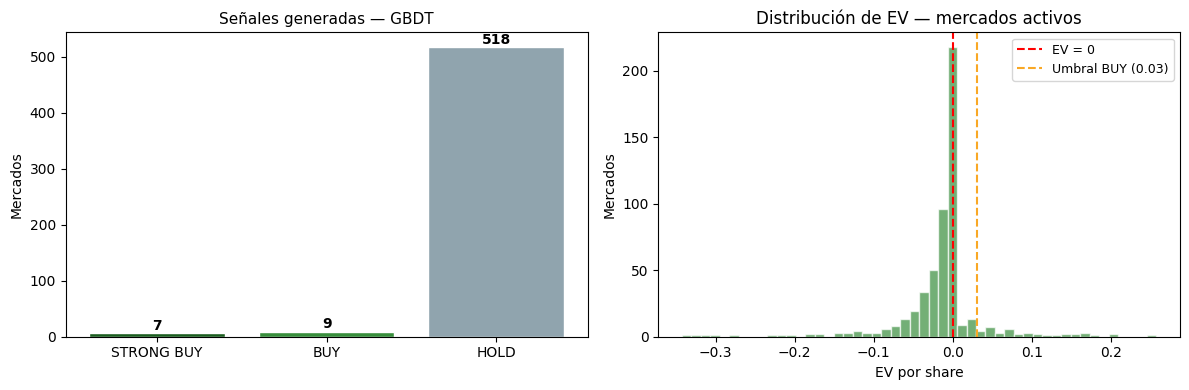

In [4]:
signal_counts = df_scores['signal'].value_counts().reindex(['STRONG BUY', 'BUY', 'HOLD'], fill_value=0)
print('Distribución de señales:')
for sig, cnt in signal_counts.items():
    pct = 100 * cnt / len(df_scores)
    print(f'  {sig:12s}: {cnt:4d}  ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
colors_sig = {'STRONG BUY': '#1B5E20', 'BUY': '#388E3C', 'HOLD': '#90A4AE'}
ax.bar(signal_counts.index, signal_counts.values,
       color=[colors_sig[s] for s in signal_counts.index], edgecolor='white')
for bar, (sig, cnt) in zip(ax.patches, signal_counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Señales generadas — GBDT', fontsize=11)
ax.set_ylabel('Mercados')

ax = axes[1]
ax.hist(df_scores['ev_per_share'], bins=50, color='#388E3C', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', lw=1.5, ls='--', label='EV = 0')
ax.axvline(0.03, color='#F9A825', lw=1.5, ls='--', label='Umbral BUY (0.03)')
ax.set_xlabel('EV por share')
ax.set_ylabel('Mercados')
ax.set_title('Distribución de EV — mercados activos')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_live_signals.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Top señales filtradas por liquidez

In [5]:
scoring_cfg = cfg.get('scoring', {})
min_liq   = scoring_cfg.get('min_liquidity', 1000)
min_vol   = scoring_cfg.get('min_volume_24h', 100)
max_spread = scoring_cfg.get('max_spread', 0.10)

df_actionable = df_scores[
    df_scores['signal'].isin(['BUY', 'STRONG BUY'])
].copy()

# Filtros de liquidez (si las columnas existen)
if 'liquidity' in df_actionable.columns:
    df_actionable = df_actionable[df_actionable['liquidity'] >= min_liq]
if 'volume_24h' in df_actionable.columns:
    df_actionable = df_actionable[df_actionable['volume_24h'] >= min_vol]
if 'spread' in df_actionable.columns:
    df_actionable = df_actionable[df_actionable['spread'] <= max_spread]

df_actionable = df_actionable.sort_values('ev_per_share', ascending=False)

print(f'Señales accionables (post-filtro): {len(df_actionable):,}')
print(f'Filtros: liquidez≥{min_liq}, volumen_24h≥{min_vol}, spread≤{max_spread}')
print()

cols_show = ['question', 'price_yes', 'p_yes_calibrated', 'ev_per_share',
             'expected_roi_capped', 'days_to_end', 'signal']
available = [c for c in cols_show if c in df_actionable.columns]
display(df_actionable[available].head(15).style.format({
    'price_yes': '{:.3f}',
    'p_yes_calibrated': '{:.3f}',
    'ev_per_share': '{:.4f}',
    'expected_roi_capped': '{:.3f}',
    'days_to_end': '{:.0f}',
}))

Señales accionables (post-filtro): 16
Filtros: liquidez≥1000.0, volumen_24h≥100.0, spread≤0.1



,question,price_yes,p_yes_calibrated,ev_per_share,expected_roi_capped,days_to_end,signal
1069,"Will another country conduct military action against Iran by April 30, 2026?",0.280,0.487,0.2074,0.741,17,STRONG BUY
1070,"Will Bitcoin dip to $65,000 in April?",0.625,0.824,0.1986,0.318,18,STRONG BUY
1075,"Will another country conduct military action against Iran by April 15, 2026?",0.165,0.325,0.1597,0.968,2,STRONG BUY
1076,Will Ukraine re-enter Rodynske by April 30?,0.470,0.624,0.1542,0.328,17,STRONG BUY
1077,Will WTI Crude Oil (WTI) hit (HIGH) $120 in April?,0.685,0.824,0.1392,0.203,18,STRONG BUY
1078,Rolex Monte Carlo Masters: Andrey Rublev vs Nuno Borges,0.760,0.899,0.1389,0.183,0,BUY
1079,"Will Ethereum reach $2,200 in April?",0.845,0.977,0.1317,0.156,18,BUY
1080,US x Iran ceasefire by April 15?,0.155,0.270,0.1153,0.744,2,STRONG BUY
1082,Will the Kharg Island oil terminal be hit by April 30?,0.375,0.486,0.1109,0.296,17,STRONG BUY
1085,Indian Premier League: Kolkata Knight Riders vs Punjab Kings,0.455,0.544,0.0894,0.196,0,BUY


## 5. Backtest offline en test set — por horizonte

Estos resultados son del held-out test temporal. No son del live scoring de activos — son la validación real del modelo.

In [6]:
by_horizon = tm.get('by_horizon', {})

bucket_rows = []
for bucket_name, bucket_data in by_horizon.items():
    prob_m = bucket_data.get('probability_metrics', {})
    mkt_m  = bucket_data.get('market_baseline_metrics', {})
    ev_m   = bucket_data.get('ev_metrics', {})
    bucket_rows.append({
        'Horizonte': bucket_name.replace('_', ' '),
        'n': bucket_data.get('count', 0),
        'Brier GBDT': prob_m.get('brier'),
        'Brier Mkt': mkt_m.get('brier'),
        'ROC-AUC': prob_m.get('roc_auc'),
        'Top-K hit': ev_m.get('top_k_hit_rate'),
        'Top-K PnL': ev_m.get('top_k_avg_realized_pnl'),
    })

df_bkt = pd.DataFrame(bucket_rows)
display(df_bkt.style.format({
    'Brier GBDT': '{:.4f}',
    'Brier Mkt':  '{:.4f}',
    'ROC-AUC':    '{:.4f}',
    'Top-K hit':  '{:.0%}',
    'Top-K PnL':  '{:.4f}',
}))

,Horizonte,n,Brier GBDT,Brier Mkt,ROC-AUC,Top-K hit,Top-K PnL
0,short 1 3d,2380,0.0036,0.0052,0.9998,39%,0.0112
1,medium 4 14d,2380,0.0034,0.0052,0.9998,40%,0.0139
2,long 15plus,1167,0.0089,0.0101,0.9991,62%,0.0829


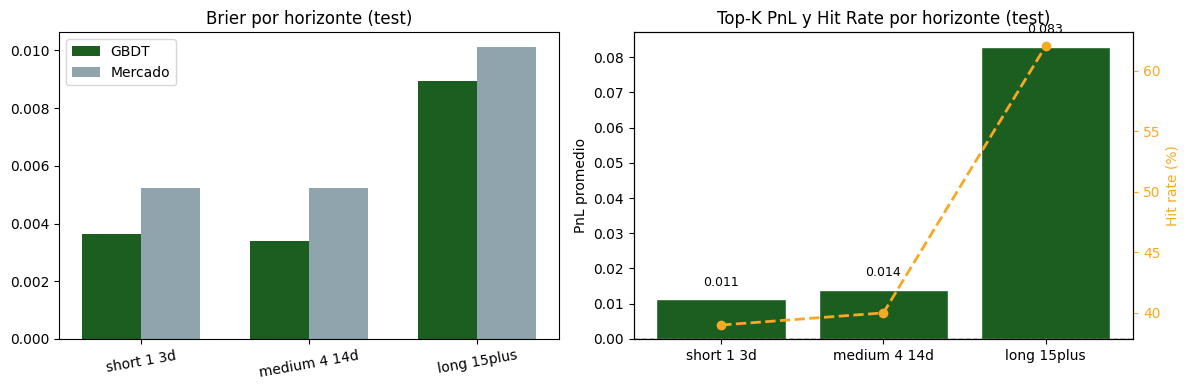

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x = np.arange(len(df_bkt))
w = 0.35
ax.bar(x - w/2, df_bkt['Brier GBDT'], w, label='GBDT', color='#1B5E20')
ax.bar(x + w/2, df_bkt['Brier Mkt'],  w, label='Mercado', color='#90A4AE')
ax.set_xticks(x)
ax.set_xticklabels(df_bkt['Horizonte'], rotation=10)
ax.set_title('Brier por horizonte (test)')
ax.legend()

ax = axes[1]
pnl_vals = df_bkt['Top-K PnL'].fillna(0)
hit_vals  = df_bkt['Top-K hit'].fillna(0)
colors_b = ['#1B5E20' if v > 0 else '#EF9A9A' for v in pnl_vals]
bars = ax.bar(df_bkt['Horizonte'], pnl_vals, color=colors_b, edgecolor='white')
ax2 = ax.twinx()
ax2.plot(df_bkt['Horizonte'], hit_vals * 100, 'o--', color='#F9A825', lw=2, label='Hit rate %')
ax2.set_ylabel('Hit rate (%)', color='#F9A825')
ax2.tick_params(axis='y', colors='#F9A825')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title('Top-K PnL y Hit Rate por horizonte (test)')
ax.set_ylabel('PnL promedio')
for bar, v in zip(bars, pnl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'gbdt_live_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Resumen operativo

In [8]:
n_buy = (df_scores['signal'] == 'BUY').sum()
n_sbuy = (df_scores['signal'] == 'STRONG BUY').sum()
n_action = len(df_actionable)

print('Lectura rápida:')
print(f"  Mercados activos analizados  : {len(df_scores):,}")
print(f"  Señales BUY                  : {n_buy}")
print(f"  Señales STRONG BUY           : {n_sbuy}")
print(f"  Accionables (post-liquidez)  : {n_action}")
print()
print('Validación offline (test set):')
print(f"  Brier    : {raw['brier']:.5f}  vs mercado {mkt['brier']:.5f}  {'✓ GANA' if beaten.get('brier') else '✗ pierde'}")
print(f"  Log-loss : {raw['log_loss']:.5f}  vs mercado {mkt['log_loss']:.5f}  {'✓ GANA' if beaten.get('log_loss') else '✗ pierde'}")
print(f"  Top-K hit rate : {ev.get('top_k_hit_rate')}")
print(f"  Top-K PnL prom : {ev.get('top_k_avg_realized_pnl', 0):.4f}")
print()
print('Para regenerar el scoring:')
print('  python -m src.scoring.scorer --config config/config.yaml --all-models')

Lectura rápida:
  Mercados activos analizados  : 534
  Señales BUY                  : 9
  Señales STRONG BUY           : 7
  Accionables (post-liquidez)  : 16

Validación offline (test set):
  Brier    : 0.00459  vs mercado 0.00618  ✓ GANA
  Log-loss : 0.01770  vs mercado 0.02210  ✓ GANA
  Top-K hit rate : 0.77
  Top-K PnL prom : 0.1102

Para regenerar el scoring:
  python -m src.scoring.scorer --config config/config.yaml --all-models
